# Supplementary Figure S13: RT Crossover Sharpness

Supplementary Figure S13 compares the entropy of two boundary intervals with the two competing RT candidates as the separation between the intervals is varied.

This figure includes:

* the quench-and-measure entropy $S(A \cup B)$ averaged over all boundary rotations
* vertical one-standard-deviation error bars over boundary rotations
* the connected and disconnected RT candidates from the single-interval CFT fit
* the pointwise RT minimum and the candidate-crossing separation $d_*$


## Import Dependencies

In [98]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import hashlib
import json
import os
import pickle
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

os.environ.setdefault("MPLCONFIGDIR", str(Path("outputs/mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.transforms import Bbox
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

import loadconfig as loco
from graph2grav import gaussian
from graph2grav.analysis import Analysis
from graph2grav.analytic_entropies import periodic_CFT_entropy
from graph2grav.figure_hashing import save_figure_with_hash
from graph2grav.graphs.standard import crosslinked_tree, make_tree_periodic

config = loco.reload()
plt.rcParams.update({"figure.dpi": 120})


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set Parameters

Choose the MERA size, interval size, squeezing, and visual style for the crossover diagnostic.

In [109]:
FIGURE_PATH = Path("figures/supplementary-figure_rt-crossover-sharpness.pdf")
CACHE_DIR = Path("outputs/notebook_cache/S04_rt_crossover_sharpness")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_VERSION = 1
USE_NOTEBOOK_CACHE = True
CLEAR_NOTEBOOK_CACHE = False
EXPORT_OUTPUTS = True

MERA_DEPTH = 7
COUPLING_TIME = 1.0
MU = 0.1
REGION_SIZE = 16
MAX_SEPARATION = None

POINT_COLOR = "#d94b6a"
ERRORBAR_COLOR = "#f2b8c6"
CONNECTED_COLOR = "#2b7bba"
DISCONNECTED_COLOR = "#e89132"
MINIMUM_COLOR = "#2f2f2f"
TRANSITION_COLOR = "#737373"

G_tree = crosslinked_tree(depth=MERA_DEPTH)
G = make_tree_periodic(G_tree, remove_nodes=False)
analysis = Analysis(
    G,
    couplingtime=COUPLING_TIME,
    global_presqueeze=MU,
    is_decorated=False,
)
L = analysis.boundary_length
if MAX_SEPARATION is None:
    MAX_SEPARATION = L - 2 * REGION_SIZE
separations = np.arange(1, MAX_SEPARATION + 1)

boundary_cov_interwoven = gaussian.to_inter(analysis.boundary_after_bulk_measurement)
print(f"Undecorated MERA disk: L={L}, R_b={MERA_DEPTH}, |A|=|B|={REGION_SIZE}, mu={MU}")


Undecorated MERA disk: L=128, R_b=7, |A|=|B|=16, mu=0.1


## Define Helpers

Construct the two intervals on the boundary circle, evaluate their entropy, and locate the RT candidate crossing.

In [110]:
def boundary_interval(start, length, total_length):
    return [int((start + offset) % total_length) for offset in range(length)]


def two_interval_positions(origin, region_size, separation, total_length):
    first = boundary_interval(origin, region_size, total_length)
    second_start = origin + region_size + separation
    second = boundary_interval(second_start, region_size, total_length)
    return first + second


def entropy_for_positions(positions):
    return float(
        gaussian.calculate_boundary_entropy(
            boundary_cov_interwoven,
            positions,
            analysis.boundary_nodes_map,
        )
    )


def average_single_interval_entropies():
    lengths = np.arange(1, L)
    means = []
    stds = []
    for length in tqdm(lengths, desc="single-interval lengths"):
        values = np.array([
            entropy_for_positions(boundary_interval(origin, int(length), L))
            for origin in range(L)
        ])
        means.append(values.mean())
        stds.append(values.std())
    return lengths, np.asarray(means), np.asarray(stds)


def fit_average_single_interval_entropy(lengths, entropies):
    def fit_function(length, c, offset):
        return periodic_CFT_entropy(length, L, central_charge=c, offset=offset)

    popt, pcov = curve_fit(fit_function, lengths, entropies, p0=[1.0, 0.0])
    return {
        "central_charge": float(popt[0]),
        "offset": float(popt[1]),
        "central_charge_stderr": float(np.sqrt(pcov[0, 0])),
        "offset_stderr": float(np.sqrt(pcov[1, 1])),
    }


def cft_entropy(length):
    length = int(length)
    if length <= 0 or length >= L:
        return 0.0
    return float(
        periodic_CFT_entropy(
            length,
            L,
            central_charge=central_charge,
            offset=cft_offset,
        )
    )


def crossings_from_candidates(x_values, connected, disconnected):
    diff = np.asarray(connected) - np.asarray(disconnected)
    sign_changes = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    crossings = []
    for index in sign_changes:
        i = int(index)
        x0, x1 = float(x_values[i]), float(x_values[i + 1])
        y0, y1 = float(diff[i]), float(diff[i + 1])
        crossings.append(x0 - y0 * (x1 - x0) / (y1 - y0))
    return crossings


## Compute Crossover Data

For each separation, average $S(A \cup B)$ over all boundary rotations and compute the two CFT/RT candidates.

In [111]:
def cache_path_for(prefix, key):
    encoded = json.dumps(key, sort_keys=True).encode()
    digest = hashlib.sha256(encoded).hexdigest()[:16]
    return CACHE_DIR / f"{prefix}_{digest}.pkl"


def load_or_compute_cache(prefix, key, compute):
    cache_path = cache_path_for(prefix, key)
    if CLEAR_NOTEBOOK_CACHE and cache_path.exists():
        cache_path.unlink()

    if USE_NOTEBOOK_CACHE and cache_path.exists():
        with cache_path.open("rb") as handle:
            value = pickle.load(handle)
        print(f"Loaded cached {prefix} data from {cache_path}")
        return value

    value = compute()
    if USE_NOTEBOOK_CACHE:
        with cache_path.open("wb") as handle:
            pickle.dump(value, handle)
        print(f"Cached {prefix} data to {cache_path}")
    return value


def single_interval_cache_key():
    return {
        "cache_version": CACHE_VERSION,
        "mera_depth": MERA_DEPTH,
        "coupling_time": COUPLING_TIME,
        "mu": MU,
        "boundary_length": int(L),
        "fit": "origin_averaged_single_interval",
    }


def two_interval_cache_key():
    return {
        "cache_version": CACHE_VERSION,
        "mera_depth": MERA_DEPTH,
        "coupling_time": COUPLING_TIME,
        "mu": MU,
        "region_size": REGION_SIZE,
        "max_separation": int(MAX_SEPARATION),
        "boundary_length": int(L),
        "observable": "origin_averaged_two_interval_entropy",
    }


def compute_single_interval_data():
    single_interval_lengths, single_interval_mean, single_interval_std = average_single_interval_entropies()
    single_interval_fit = fit_average_single_interval_entropy(
        single_interval_lengths,
        single_interval_mean,
    )
    return {
        "single_interval_lengths": single_interval_lengths,
        "single_interval_mean": single_interval_mean,
        "single_interval_std": single_interval_std,
        "single_interval_fit": single_interval_fit,
    }


def compute_two_interval_data():
    state_entropies_by_separation = []
    for separation in tqdm(separations, desc="two-interval separations"):
        values = [
            entropy_for_positions(two_interval_positions(origin, REGION_SIZE, int(separation), L))
            for origin in range(L)
        ]
        state_entropies_by_separation.append(values)

    state_entropies_by_separation = np.asarray(state_entropies_by_separation)
    return {
        "state_entropies_by_separation": state_entropies_by_separation,
        "state_mean": state_entropies_by_separation.mean(axis=1),
        "state_std": state_entropies_by_separation.std(axis=1),
    }


single_interval_data = load_or_compute_cache(
    "single_interval",
    single_interval_cache_key(),
    compute_single_interval_data,
)
two_interval_data = load_or_compute_cache(
    "two_interval",
    two_interval_cache_key(),
    compute_two_interval_data,
)

single_interval_fit = single_interval_data["single_interval_fit"]
central_charge = single_interval_fit["central_charge"]
cft_offset = single_interval_fit["offset"]
state_mean = two_interval_data["state_mean"]
state_std = two_interval_data["state_std"]


def fitted_cft_entropy(length):
    length = int(length)
    if length <= 0 or length >= L:
        return 0.0
    return float(
        periodic_CFT_entropy(
            length,
            L,
            central_charge=central_charge,
            offset=cft_offset,
        )
    )


rt_disconnected = np.full_like(separations, 2 * fitted_cft_entropy(REGION_SIZE), dtype=float)
rt_connected = np.array([
    fitted_cft_entropy(int(separation)) + fitted_cft_entropy(L - 2 * REGION_SIZE - int(separation))
    for separation in separations
])
rt_minimum = np.minimum(rt_connected, rt_disconnected)
rt_transitions = crossings_from_candidates(separations, rt_connected, rt_disconnected)

print(f"origin-averaged single-interval CFT fit: c={central_charge:.3f}, epsilon={cft_offset:.3f}")
print(f"Computed {len(separations)} separations and {L} boundary rotations per separation.")
if not rt_transitions:
    print("No RT candidate crossing found in the plotted separation range.")


Loaded cached single_interval data from outputs/notebook_cache/S13_rt_crossover_sharpness/single_interval_78ca4e4cce69eb6c.pkl
Loaded cached two_interval data from outputs/notebook_cache/S13_rt_crossover_sharpness/two_interval_7dd0fdf4d724bb35.pkl
origin-averaged single-interval CFT fit: c=7.564, epsilon=12.847
Computed 96 separations and 128 boundary rotations per separation.


## Make Figure

Plot the lattice entropy, rotational spread, RT candidates, RT minimum, and candidate crossing.

Saved figure to figures/supplementary-figure_rt-crossover-sharpness.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=75c6ea561eabb42d, data_hash=d79f9083fafb478d, size=34223 bytes.


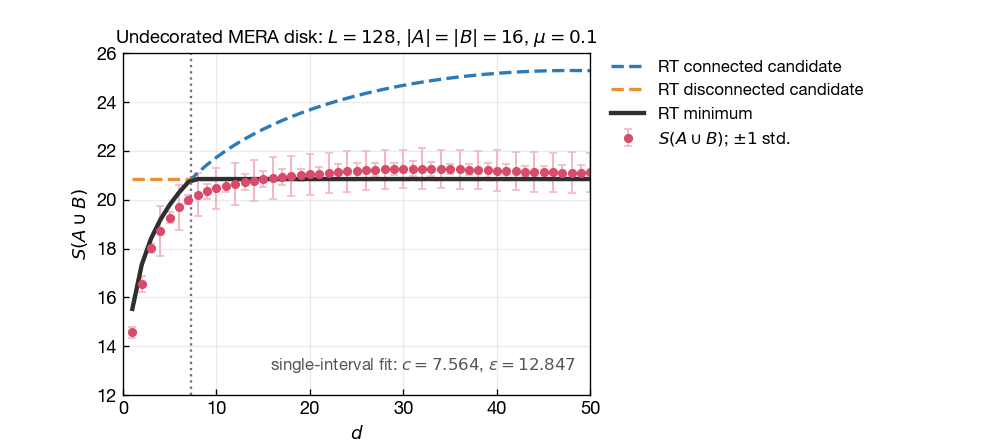

In [114]:
bbox = Bbox.from_bounds(0.0, 0.0, 8.2, 3.7)
%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

fig, ax = plt.subplots(figsize=(bbox.width, bbox.height))
fig.subplots_adjust(right=0.60)

state_points = ax.errorbar(
    separations,
    state_mean,
    yerr=state_std,
    fmt="o",
    color=POINT_COLOR,
    ecolor=ERRORBAR_COLOR,
    elinewidth=1.2,
    capsize=2.2,
    capthick=1.0,
    markersize=4.5,
    label=r"$S(A \cup B)$; $\pm 1$ std.",
)
connected_line = ax.plot(
    separations,
    rt_connected,
    "--",
    color=CONNECTED_COLOR,
    linewidth=2.0,
    label="RT connected candidate",
)[0]
disconnected_line = ax.plot(
    separations,
    rt_disconnected,
    "--",
    color=DISCONNECTED_COLOR,
    linewidth=2.0,
    label="RT disconnected candidate",
)[0]
minimum_line = ax.plot(
    separations,
    rt_minimum,
    "-",
    color=MINIMUM_COLOR,
    linewidth=2.6,
    label="RT minimum",
)[0]

for rt_transition in rt_transitions:
    ax.axvline(rt_transition, color=TRANSITION_COLOR, linestyle=":", linewidth=1.4)

ax.text(
    0.97,
    0.06,
    rf"single-interval fit: $c={central_charge:.3f}$, $\epsilon={cft_offset:.3f}$",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="#555555",
)

ax.set_title(rf"Undecorated MERA disk: $L={L}$, $|A|=|B|={REGION_SIZE}$, $\mu={MU}$")
ax.set_xlabel(r"$d$")
ax.set_ylabel(r"$S(A \cup B)$")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", bbox_to_anchor=(1.03, 1.0), frameon=False, borderaxespad=0.0, fontsize=10)

# for these particular settings, this is a good range to show the transition clearly
ax.set_ylim(bottom=12.0,top=26.0)
ax.set_xlim(left=0.0, right=50.0)

if EXPORT_OUTPUTS:
    save_figure_with_hash(fig, FIGURE_PATH, bbox_inches=bbox)
